# Introduction to PK/PD Modeling
**Systems Biology | UConn Biomedical Sciences**

Estimated time: 90–120 minutes

---

This notebook walks through the fundamentals of pharmacokinetic (PK) and pharmacodynamic (PD) modeling using R. We will move from simple analytic solutions to real data fitting to population models, building both mathematical fluency and biological intuition along the way.

## Learning Objectives

By the end of this notebook you will be able to:

1. **Distinguish PK from PD** and explain what each branch of pharmacometrics measures
2. **Interpret the biological meaning** of clearance (CL), volume of distribution (V), and absorption rate constant (ka)
3. **Write the ODEs and analytic solutions** for 1-compartment PK models (IV bolus and oral)
4. **Fit a mechanistic oral PK model** to real data using `nls()`
5. **Use a fitted model to simulate what-if dosing scenarios**, including multiple dosing and steady state
6. **Understand why population (NLME) models** are needed when you have data from multiple subjects
7. **Apply the Emax model** to relate drug concentration to pharmacological effect
8. **Appreciate the role of numerical ODE solvers** for models where analytic solutions don't exist

## Setup

We use three packages throughout this notebook:

- **`ggplot2`**: a powerful, grammar-based plotting system. Every plot we make will use it.
- **`dplyr`**: provides intuitive data manipulation verbs (`filter`, `mutate`, `summarize`, etc.)
- **`tidyr`**: tools for reshaping data between wide and long formats

If you have not installed these before, run `install.packages(c("ggplot2", "dplyr", "tidyr", "nlme", "deSolve", "gridExtra"))` once in your R session.

In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)

# Set default plot dimensions for Jupyter display
options(repr.plot.width = 10, repr.plot.height = 5)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




If you see no error messages, all packages loaded successfully. The `options()` call ensures our plots are wide enough to display clearly in the notebook.

---
## Part 1: PK vs PD — What Are We Modeling?

### The Pharmacometrics Tree

<img src="images/pmx-tree.png" width="750">

**Pharmacometrics** is the science of quantitative pharmacology. It sits at the intersection of mathematics, statistics, and drug science. Its two main branches are pharmacokinetics and pharmacodynamics.

---

### Pharmacokinetics (PK): What the *body does to the drug*

PK tracks the **concentration of drug** in the body (usually plasma) as a function of time. The processes involved are summarized by the acronym **ADME**:

| Process | What happens |
|---|---|
| **A**bsorption | Drug enters the bloodstream from the dose site (gut, muscle, skin, etc.) |
| **D**istribution | Drug moves from blood into tissues and organs |
| **M**etabolism | Drug is chemically transformed, usually in the liver |
| **E**limination | Drug and metabolites are excreted, usually via kidneys |

The output of a PK model is a **concentration–time curve**: $C(t)$.

---

### Pharmacodynamics (PD): What the *drug does to the body*

PD maps **drug concentration to biological effect**. The effect might be:
- Receptor activation (fractional occupancy)
- Enzyme inhibition (% inhibition)
- A clinical endpoint (blood pressure, tumor volume, heart rate)

The output of a PD model is an **effect–concentration relationship**: $E(C)$.

---

### The Full PK/PD Chain

<img src="images/pkpd-diagram.png" width="480">

The complete quantitative story is:

$$\text{Dose} \xrightarrow{\text{PK}} C(t) \xrightarrow{\text{PD}} E(t)$$

A dose is administered → PK determines the concentration at each time point → PD converts that concentration into an effect at each time point.

---

### What PK/PD Profiles Look Like

<img src="images/pkpd-plots-concept.png" width="580">

The left panel shows a typical oral PK profile: concentration rises during absorption, reaches a peak (Tmax, Cmax), then falls during elimination. The right panel shows the corresponding effect profile — it may not track concentration identically, because the drug–receptor interaction introduces its own dynamics.

---

### Why Build a Model Instead of Just Looking at the Data?

| Question | Raw data alone | With a PK/PD model |
|---|---|---|
| What dose gives therapeutic concentrations in a 120 kg patient? | Cannot answer without testing that patient | Predict using CL and V scaled by body weight |
| How often should the drug be dosed? | Can only answer for the interval actually studied | Simulate any interval and check against therapeutic window |
| Why does Subject A need 3× the dose of Subject B? | "They're just different" | Quantify inter-individual variability in CL and V; look for covariates |
| Will concentrations build up dangerously at steady state? | Need a long multi-dose study | Compute analytically from PK parameters |
| At what concentration does the drug lose efficacy? | Requires dense PD data at many concentrations | Estimate EC50 from concentration–effect relationship |

---
## Part 2: A Brief History — Where Did This Come From?

<img src="images/torsten-model.png" width="520">

This is Torsten Teorell's 1937 diagram — one of the earliest physiologically-based PK models. Teorell proposed modeling the body as **interconnected compartments** representing blood, tissues, and organs, each linked by rate constants governing drug transfer.

His key insight: **drug movement obeys the same differential equations as chemical kinetics**. Specifically, if a drug is removed from a compartment at a rate proportional to its current amount (first-order kinetics), the resulting concentration–time profile is a sum of exponentials — exactly what clinicians observed empirically.

Modern PK modeling descends directly from Teorell's framework. The compartments have become more abstract ("central" and "peripheral" rather than literal organs), but the mathematical structure is identical.

Two other landmarks:
- **1960s–70s**: John Wagner and others formalized the one- and two-compartment models with analytic solutions and connected them to clinical data
- **1980s**: Sheiner, Beal, and colleagues developed **nonlinear mixed-effects (NLME)** modeling, enabling population-level analysis of drug data — the approach used in modern drug development today

---
## Part 3: PK Models

### 3a. One-Compartment IV Bolus

<img src="images/1cpt-iv.png" width="220">

The simplest model: the entire body is treated as a single, well-mixed "box" (compartment). Drug is injected directly into the bloodstream (IV bolus), so there is no absorption phase — concentration starts high and decays from that point.

#### The ODE

$$\frac{dC}{dt} = -k_e C, \qquad C(0) = \frac{\text{Dose}}{V}$$

In plain English: the rate of change of concentration equals a constant fraction $k_e$ times the current concentration, with a minus sign because drug is leaving. The initial concentration is the dose divided by the volume it distributes into.

#### Analytic Solution

$$C(t) = \frac{\text{Dose}}{V}\, e^{-k_e t}$$

This is pure exponential decay. Starting from $C_0 = \text{Dose}/V$, concentration falls by the same *fraction* in every equal time interval.

#### Key Parameters

| Parameter | Symbol | Biological meaning | Typical units |
|---|---|---|---|
| Clearance | CL | Volume of plasma completely cleared of drug per unit time | L/h |
| Volume of distribution | V | Apparent volume into which drug distributes at equilibrium | L |
| Elimination rate constant | $k_e = \text{CL}/V$ | Fractional rate of drug removal | h⁻¹ |
| Half-life | $t_{1/2} = \ln(2)/k_e$ | Time for concentration to fall by 50% | h |

> **Critical insight**: $k_e$ is a *derived* quantity — it is determined by both CL and V. A drug can have a long half-life either because CL is small (slow elimination) or because V is large (drug is sequestered in tissues and hard to remove). Half-life alone does not tell you why.

#### Semilog Plot

<img src="images/1cpt-bolus-lin-log.png" width="600">

On a linear scale, the concentration curve bends (it is exponential). On a **semilog** (log y-axis) scale, exponential decay becomes a straight line. The slope of that line is $-k_e$, which makes $k_e$ and $t_{1/2}$ directly readable from the graph. This is why clinical PK reports almost always show semilog plots.

Let's simulate the IV bolus model in R and explore how CL and V independently affect the concentration–time profile.


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




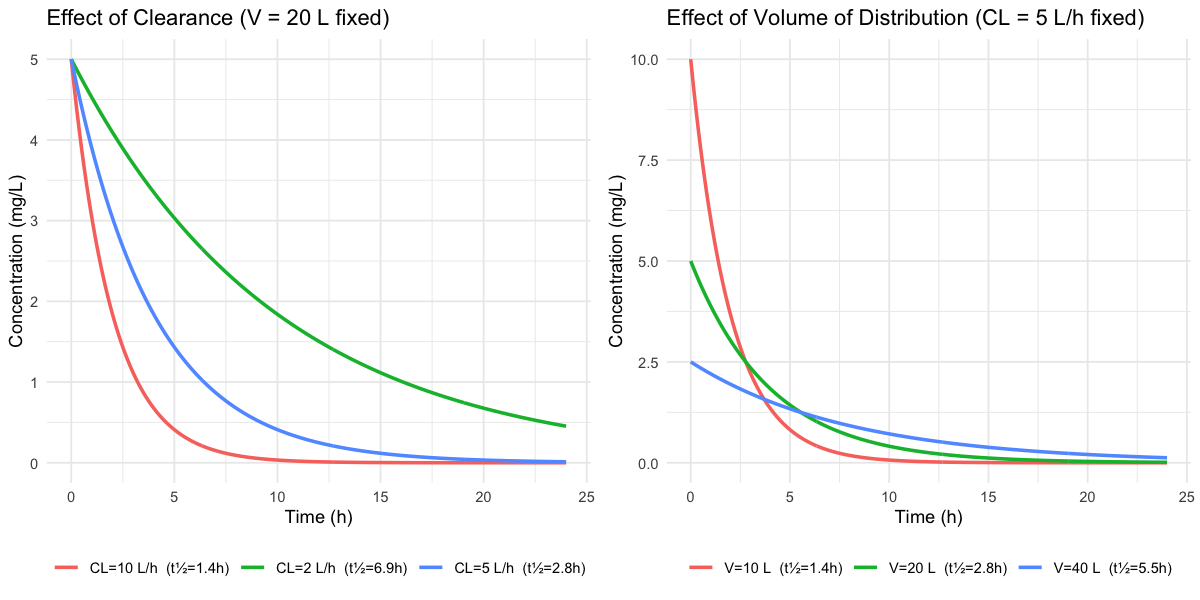

In [2]:
# Analytic solution: 1-compartment IV bolus
# Returns concentration (mg/L) at each time in vector t
pk_iv_bolus <- function(t, dose, CL, V) {
  ke <- CL / V
  (dose / V) * exp(-ke * t)
}

t_seq <- seq(0, 24, by = 0.05)  # time grid from 0 to 24 hours
dose  <- 100  # mg

# --- Panel 1: vary CL, hold V fixed ---
# expand.grid creates every combination of t and CL
df_CL <- expand.grid(t = t_seq, CL = c(2, 5, 10)) %>%
  mutate(
    V      = 20,
    ke     = CL / V,
    t_half = round(log(2) / ke, 1),
    label  = paste0("CL=", CL, " L/h  (t½=", t_half, "h)"),
    C      = pk_iv_bolus(t, dose, CL, V)
  )

p1 <- ggplot(df_CL, aes(x = t, y = C, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Effect of Clearance (V = 20 L fixed)",
    x = "Time (h)", y = "Concentration (mg/L)", color = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

# --- Panel 2: vary V, hold CL fixed ---
df_V <- expand.grid(t = t_seq, V = c(10, 20, 40)) %>%
  mutate(
    CL     = 5,
    ke     = CL / V,
    t_half = round(log(2) / ke, 1),
    label  = paste0("V=", V, " L  (t½=", t_half, "h)"),
    C      = pk_iv_bolus(t, dose, CL, V)
  )

p2 <- ggplot(df_V, aes(x = t, y = C, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Effect of Volume of Distribution (CL = 5 L/h fixed)",
    x = "Time (h)", y = "Concentration (mg/L)", color = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

library(gridExtra)
grid.arrange(p1, p2, ncol = 2)

**Reading these plots:**

- **Left panel** (varying CL): Higher clearance removes drug faster. CL = 10 L/h gives a t½ of only 1.4 h — drug is nearly gone by 6 hours. CL = 2 L/h gives t½ = 6.9 h.
- **Right panel** (varying V): Larger V *lowers* the initial concentration (drug distributes into a bigger volume) **and** *lengthens* the half-life, because the body must clear a larger total amount. V = 40 L gives t½ = 5.5 h vs 2.8 h for V = 10 L — even though CL is identical in all three cases.

The takeaway: **half-life is not a fundamental parameter**. It is a ratio of two independent biological properties (CL and V). A long half-life could mean either slow elimination or extensive distribution into tissues. You need to know both.

---
### 3b. One-Compartment Oral Absorption

<img src="images/1cpt-oral.png" width="240">

Most drugs are given orally. The drug must first dissolve in the gut, then cross the intestinal wall into the bloodstream. We model this with a **depot compartment** (representing the gut) that feeds into the central compartment (plasma).

#### The ODEs

$$\frac{dD}{dt} = -k_a D, \qquad D(0) = F \cdot \text{Dose}$$

$$\frac{dC}{dt} = \frac{k_a D}{V} - k_e C, \qquad C(0) = 0$$

- $D$: amount of drug remaining in the gut depot
- $k_a$: first-order absorption rate constant (h⁻¹)
- $F$: bioavailability — fraction of the dose that reaches systemic circulation (0–1)
- The first term in the $dC/dt$ equation is the absorption input; the second is elimination

#### Analytic Solution

$$C(t) = \frac{F \cdot \text{Dose} \cdot k_a}{V(k_a - k_e)}\left(e^{-k_e t} - e^{-k_a t}\right)$$

This is the **difference of two exponentials**. Early on, the $e^{-k_a t}$ term (absorption) decays faster, so $C$ rises. Later, once the depot is nearly empty, the $e^{-k_e t}$ term (elimination) dominates, and $C$ falls. The peak occurs at:

$$T_{\max} = \frac{\ln(k_a/k_e)}{k_a - k_e}$$

<img src="images/oral_model.png" width="420">

This model requires $k_a \neq k_e$ (the formula breaks down at equality — a special case called "flip-flop" that we address below).

Now let's explore how the absorption rate constant $k_a$ shapes the concentration–time profile.

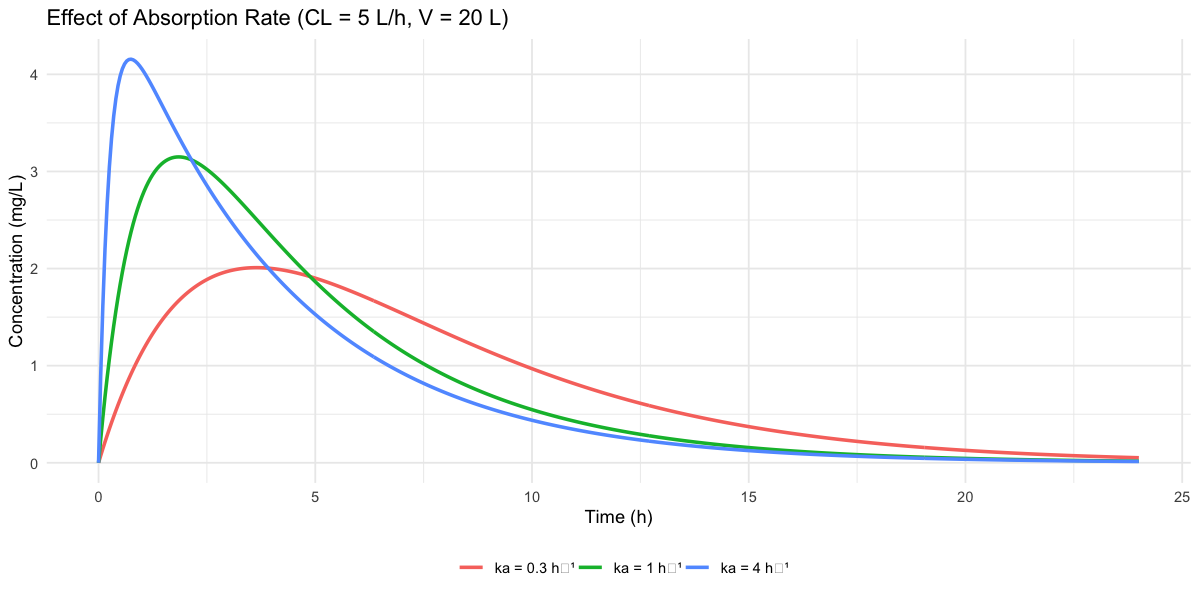

In [3]:
# Analytic solution: 1-compartment oral absorption
# F defaults to 1 (complete bioavailability) for simplicity
pk_oral <- function(t, dose, ka, CL, V, F = 1) {
  ke <- CL / V
  # Avoid division by zero if ka == ke (numerical workaround)
  if (abs(ka - ke) < 1e-6) ka <- ka * 1.0001
  (F * dose * ka) / (V * (ka - ke)) * (exp(-ke * t) - exp(-ka * t))
}

t_seq <- seq(0, 24, by = 0.05)
dose  <- 100
CL <- 5; V <- 20

# Build a data frame with three values of ka
# mapply applies pk_oral element-wise over t and ka simultaneously
df_ka <- expand.grid(t = t_seq, ka = c(0.3, 1.0, 4.0)) %>%
  mutate(
    label = paste0("ka = ", ka, " h⁻¹"),
    C     = mapply(pk_oral, t, dose, ka, CL, V)
  )

ggplot(df_ka, aes(x = t, y = C, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Effect of Absorption Rate (CL = 5 L/h, V = 20 L)",
    x = "Time (h)", y = "Concentration (mg/L)", color = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

**Observations:**

- **Slow absorption** (ka = 0.3 h⁻¹): drug trickles into plasma slowly. The peak is low and broad, occurring late (around 8 h). Area under the curve (AUC) is the same — you get the same total drug exposure, just stretched out.
- **Fast absorption** (ka = 4.0 h⁻¹): drug absorbs almost instantly. The profile resembles an IV bolus with a sharp early peak.
- **Intermediate** (ka = 1.0 h⁻¹): typical oral drug behavior.

**Flip-flop kinetics** (not shown): if ka < ke, absorption is the rate-limiting step. The terminal slope of the log-concentration curve reflects ka, not ke. This can be mistaken for a slow eliminator — a trap for naive analysis. The only way to identify flip-flop is to also give the drug IV.

> **Clinical relevance**: Extended-release (XR) formulations deliberately engineer a small ka to achieve a flat, prolonged profile — exactly what we see with ka = 0.3 — reducing peak toxicity and dosing frequency.

---
### 3c. Two-Compartment Model (Concept)

<img src="images/2cpt-bolus.png" width="580">

Some drugs show a **bi-phasic** decline after IV injection: a rapid initial drop ("alpha phase") followed by a slower terminal decline ("beta phase"). This happens when drug distributes into a **slowly-equilibrating peripheral compartment** — think adipose tissue, muscle, or bone marrow.

The two-compartment ODEs:

$$\frac{dA_1}{dt} = -(k_{10} + k_{12})\,A_1 + k_{21}\,A_2$$
$$\frac{dA_2}{dt} = k_{12}\,A_1 - k_{21}\,A_2$$

where $A_1$ is drug amount in the central compartment and $A_2$ is drug in the peripheral compartment. The transfer rate constants $k_{12}$ and $k_{21}$ govern bidirectional distribution.

For the rest of this lecture we use the **one-compartment model**, which is sufficient for theophylline and many commonly used drugs. The two-compartment framework uses the same conceptual tools — just more parameters and a more complex analytic solution.

---
## Part 4: Fitting Real PK Data

### 4a. The Theophylline Dataset

Theophylline is a bronchodilator used to treat asthma and COPD. It has a narrow therapeutic window (5–15 mg/L), making accurate PK modeling clinically important — too little and it is ineffective; too much causes arrhythmias and seizures.

R's built-in `Theoph` dataset contains data from a classic PK study by Dr. Robert Boeckmann. Twelve subjects each received a single oral dose and had plasma concentrations measured at 11 time points over 25 hours.

**Variables:**
- `Subject`: subject ID (1–12)
- `Wt`: body weight in kg
- `Dose`: mg/kg (dose per kilogram body weight)
- `Time`: hours since dose
- `conc`: plasma concentration in mg/L

Let's load it and take a look.

In [4]:
# Load the built-in Theoph dataset
data(Theoph)

# Show first few rows
head(Theoph, 12)

,Subject,Wt,Dose,Time,conc
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74
2,1,79.6,4.02,0.25,2.84
3,1,79.6,4.02,0.57,6.57
4,1,79.6,4.02,1.12,10.50
5,1,79.6,4.02,2.02,9.66
6,1,79.6,4.02,3.82,8.58
7,1,79.6,4.02,5.10,8.36
8,1,79.6,4.02,7.03,7.47
9,1,79.6,4.02,9.05,6.89


Notice that Subject 1 appears multiple times — once per time point. This is **long format** data, where each row is one observation. All 12 subjects × 11 time points = 132 rows total.

Now let's plot all 12 subjects together — this is called a **spaghetti plot**.

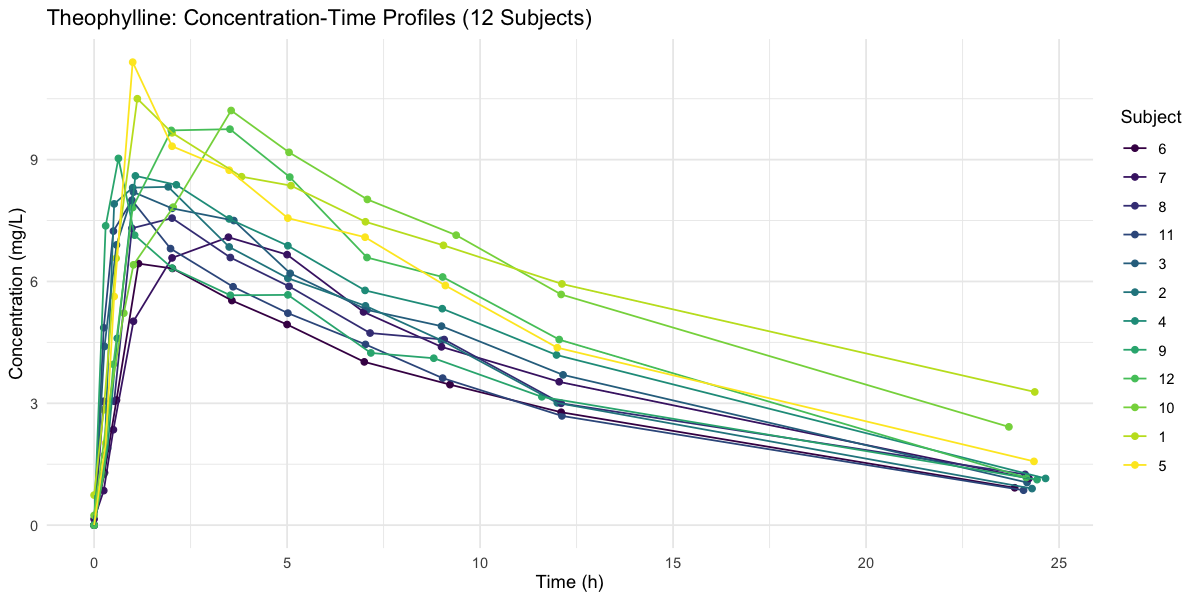

In [5]:
ggplot(Theoph, aes(x = Time, y = conc, group = Subject, color = Subject)) +
  geom_point(size = 1.5) +
  geom_line() +
  labs(
    title = "Theophylline: Concentration-Time Profiles (12 Subjects)",
    x = "Time (h)", y = "Concentration (mg/L)"
  ) +
  theme_minimal()

Despite all subjects receiving similar weight-adjusted doses, there is striking variability:

- Peak concentrations range from about 6 to 11 mg/L
- Time to peak varies from roughly 1 to 4 hours
- Elimination rates clearly differ — some subjects still have 5+ mg/L at 24 h, others have dropped below 3 mg/L

This is **inter-individual variability (IIV)** — arguably the central challenge in clinical pharmacology. It arises from genetic differences in metabolizing enzymes (CYP1A2 is the main theophylline metabolizer), co-medications, smoking status, and age.

A PK model lets us quantify *how much* variability exists in each parameter, and ultimately ask *why*.

---
### 4b. Focus on Subject 1

Before fitting all 12 subjects simultaneously, let's understand the fitting process by working with a single subject carefully.

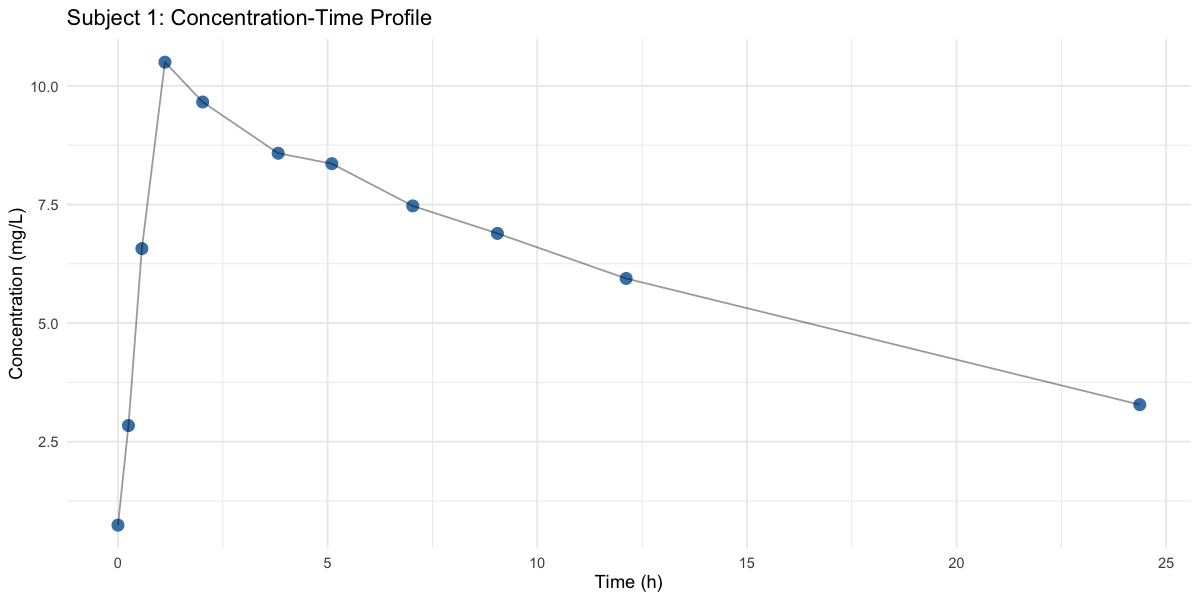

In [6]:
# Extract data for Subject 1 only
sub1 <- subset(Theoph, Subject == 1)

ggplot(sub1, aes(x = Time, y = conc)) +
  geom_point(size = 3, color = "steelblue") +
  geom_line(alpha = 0.4) +
  labs(
    title = "Subject 1: Concentration-Time Profile",
    x = "Time (h)", y = "Concentration (mg/L)"
  ) +
  theme_minimal()

The profile clearly shows two phases:
1. **Absorption phase** (0 to ~2 h): concentration rises as drug is absorbed from the gut
2. **Elimination phase** (after ~2 h): concentration falls as drug is cleared

A simple monoexponential decay cannot describe this shape — we need the oral absorption model with both $k_a$ and $k_e$. The challenge is that neither is directly observable: we have to *infer* them from how the data looks.

---
### 4c. Fitting the Oral Model with `nls()`

R's `nls()` function fits **n**on**l**inear least **s**quares models. It works by:

1. Starting with your initial parameter guesses
2. Computing the sum of squared residuals (SSR) between model predictions and observations

Mathematically, the objective is to minimize the **sum of squared residuals (SSR)**:

$$
\text{SSR} = \sum_{j} \left(y_j - f(t_j, \theta)\right)^2
$$

where $y_j$ are the observed concentrations and $f(t_j, \theta)$ are the model predictions.

3. Iteratively adjusting parameters to decrease SSR
4. Stopping when changes in SSR are negligibly small

Two important cautions:
- **Starting values matter**: unlike linear regression, `nls()` can converge to a local minimum or fail entirely if starting values are far from the truth. Use biological knowledge to guide them.
- **The model must be identifiable**: you need enough data, spread over enough time, to uniquely determine all parameters.

For theophylline, literature values suggest: $k_a \approx 1.5$ h⁻¹, $\text{CL} \approx 0.04$ L/kg/h, $V \approx 0.5$ L/kg. We will use these as starting points.

In [7]:
# Define the one-compartment oral model as an R function
# Time and Dose come from the data frame; ka, CL, V are the parameters to estimate
one_comp_oral <- function(Time, Dose, ka, CL, V) {
  ke <- CL / V
  (Dose * ka) / (V * (ka - ke)) * (exp(-ke * Time) - exp(-ka * Time))
}

# Fit to Subject 1 using nls()
# The formula says: predict conc using our model function
# start = initial parameter guesses
fit_sub1 <- nls(
  conc ~ one_comp_oral(Time, Dose, ka, CL, V),
  data  = sub1,
  start = c(ka = 1.5, CL = 0.04, V = 0.5)
)

summary(fit_sub1)


Formula: conc ~ one_comp_oral(Time, Dose, ka, CL, V)

Parameters:
   Estimate Std. Error t value Pr(>|t|)    
ka 1.777410   0.307164   5.787 0.000411 ***
CL 0.019923   0.002536   7.857 4.97e-05 ***
V  0.369264   0.022238  16.605 1.75e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.732 on 8 degrees of freedom

Number of iterations to convergence: 9 
Achieved convergence tolerance: 5.451e-06


The `summary()` output gives us:
- **Estimate**: the best-fit parameter value
- **Std. Error**: uncertainty in that estimate (from the curvature of the SSR surface)
- **t value** and **Pr(>|t|)**: significance test (are parameters significantly different from zero?)
- **Residual standard error**: average prediction error in mg/L

Now let's extract the fitted parameters and compute derived quantities.

In [8]:
# Extract the three fitted parameter values
params <- coef(fit_sub1)

# Compute derived parameters
ke_hat   <- params["CL"] / params["V"]          # elimination rate constant
t_half   <- log(2) / ke_hat                      # half-life
tmax_hat <- log(params["ka"] / ke_hat) / (params["ka"] - ke_hat)  # time of peak

cat("=== Fitted PK Parameters for Subject 1 ===\n")
cat(sprintf("  ka   = %.3f h-1   (absorption half-life = %.1f h)\n",
            params["ka"], log(2) / params["ka"]))
cat(sprintf("  CL   = %.4f L/kg/h\n", params["CL"]))
cat(sprintf("  V    = %.3f L/kg\n", params["V"]))
cat(sprintf("  ke   = CL/V = %.4f h-1\n", ke_hat))
cat(sprintf("  t1/2 = ln(2)/ke = %.1f h\n", t_half))
cat(sprintf("  Tmax (predicted) = %.1f h\n", tmax_hat))

=== Fitted PK Parameters for Subject 1 ===
  ka   = 1.777 h-1   (absorption half-life = 0.4 h)
  CL   = 0.0199 L/kg/h
  V    = 0.369 L/kg
  ke   = CL/V = 0.0540 h-1
  t1/2 = ln(2)/ke = 12.8 h
  Tmax (predicted) = 2.0 h


With just three numbers — $k_a$, CL, V — we have compressed Subject 1's entire 11-point time course into a mechanistic description. Each parameter has a clear biological meaning: CL tells us how efficiently their body clears theophylline, V tells us how widely the drug distributes.

Now let's visually check the fit.

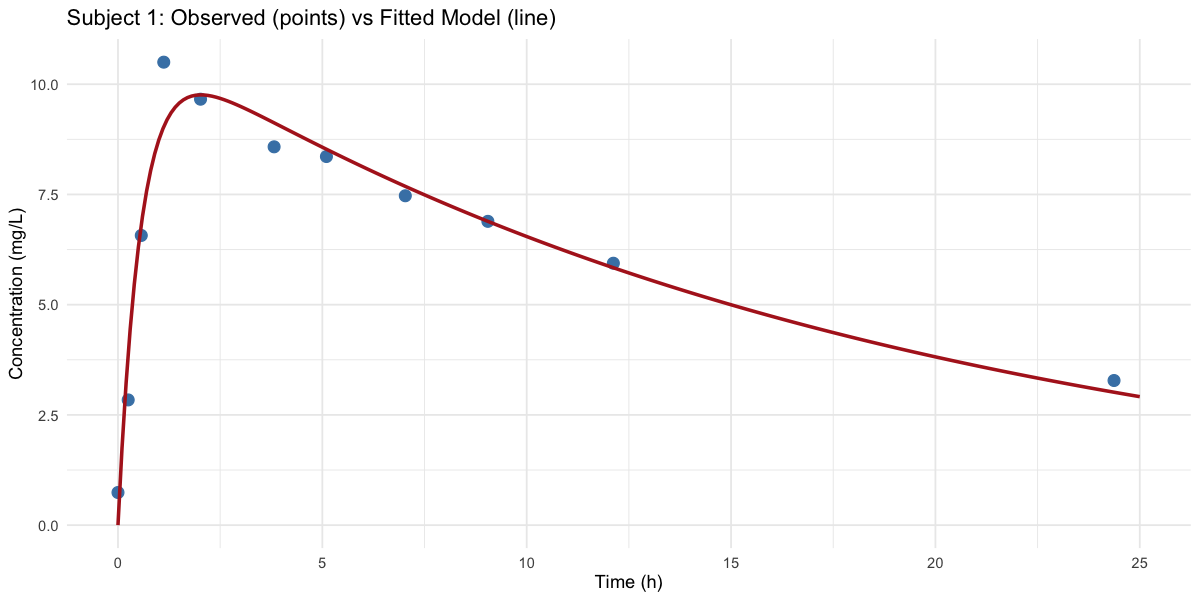

In [9]:
# Generate a smooth predicted curve on a fine time grid
t_fine   <- seq(0, 25, by = 0.1)
C_pred   <- one_comp_oral(t_fine, Dose = sub1$Dose[1],
                          ka = params["ka"], CL = params["CL"], V = params["V"])
pred_df  <- data.frame(Time = t_fine, conc = C_pred)

ggplot() +
  geom_point(data = sub1, aes(x = Time, y = conc),
             size = 3, color = "steelblue") +
  geom_line(data = pred_df, aes(x = Time, y = conc),
            color = "firebrick", linewidth = 1) +
  labs(
    title = "Subject 1: Observed (points) vs Fitted Model (line)",
    x = "Time (h)", y = "Concentration (mg/L)"
  ) +
  theme_minimal()

The model line passes cleanly through the data points, capturing both the ascending absorption phase and the descending elimination phase. The residual standard error from `summary()` gives the typical distance between a data point and the line.

If the fit looked poor (systematic deviations, e.g., the model consistently over-predicts early and under-predicts late), that would suggest the model structure is wrong — perhaps this subject needs a two-compartment model, or there is a lag time before absorption begins.

---
## Part 5: Simulation — Using the Model to Ask "What If?"

Fitting gives us parameters. But the real power of a mechanistic model is **simulation**: using those parameters to predict behavior under conditions never actually tested. Because CL and V have biological meaning, we can extrapolate confidently.

Raw data cannot answer counterfactual questions. The model can.

---
### 5a. What If the Dose Were Different?

Subject 1 received 4.02 mg/kg. What would their profile look like at 2× and 3× that dose?

Because the one-compartment oral model is **linear** in dose (concentration scales exactly proportionally), this is straightforward.

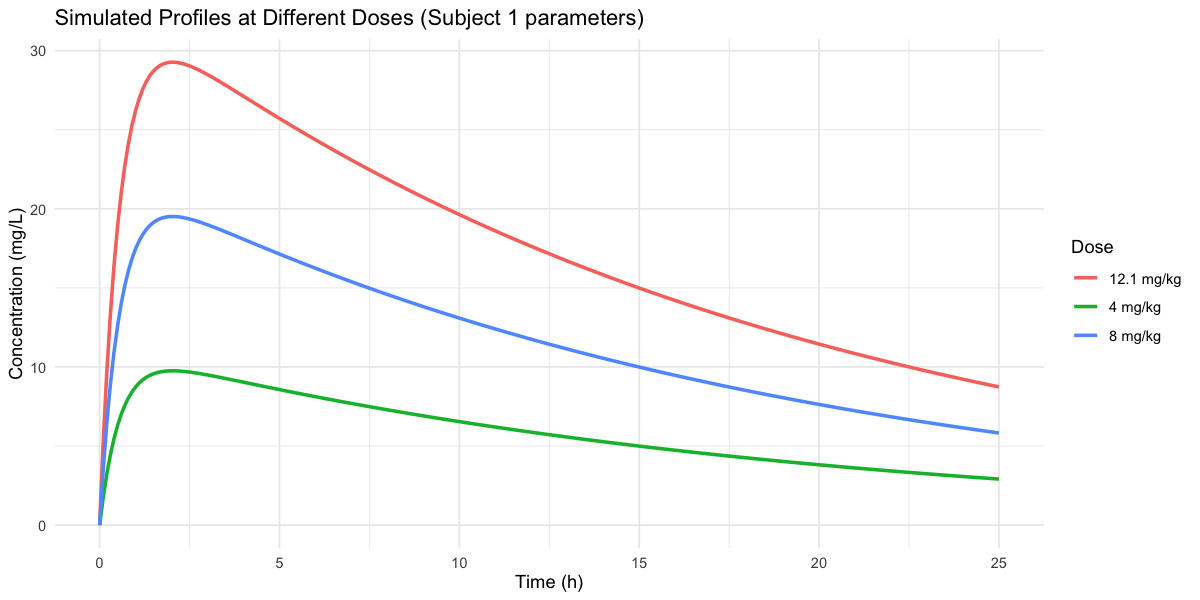

In [10]:
# Three doses: actual, 2x, 3x
doses       <- c(sub1$Dose[1], sub1$Dose[1] * 2, sub1$Dose[1] * 3)
dose_labels <- paste0(round(doses, 1), " mg/kg")

# Build predicted profiles for each dose
sim_doses <- lapply(seq_along(doses), function(i) {
  data.frame(
    Time = t_fine,
    conc = one_comp_oral(t_fine, Dose = doses[i],
                         ka = params["ka"], CL = params["CL"], V = params["V"]),
    Dose = dose_labels[i]
  )
})

# Combine into one data frame (rbind = row-bind = stack rows)
sim_df <- do.call(rbind, sim_doses)

ggplot(sim_df, aes(x = Time, y = conc, color = Dose)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Simulated Profiles at Different Doses (Subject 1 parameters)",
    x = "Time (h)", y = "Concentration (mg/L)", color = "Dose"
  ) +
  theme_minimal()

Because the model is linear, doubling the dose exactly doubles all concentrations at every time point — the shape of the curve is preserved. This linearity also means:
- AUC doubles with dose
- $T_{\max}$ is unchanged (only the height, not the timing, changes)
- $t_{1/2}$ is unchanged (it depends only on CL/V, not on dose)

Nonlinear PK (e.g., saturable metabolism via Michaelis-Menten kinetics) breaks this proportionality — high doses disproportionately increase concentrations, causing unexpected toxicity.

---
### 5b. Multiple Dosing — What Happens at Steady State?

In practice, drugs are dosed repeatedly. The critical clinical questions are:
- Does the drug accumulate to dangerous levels?
- Do trough concentrations stay above the minimum effective concentration (MEC)?
- How long until steady state is reached?

For a linear model, the concentration from multiple doses obeys **superposition**: the total concentration at any time is the sum of contributions from every previous dose.

$$C(t) = \sum_{i=0}^{n} C_{\text{single}}(t - \tau \cdot i) \cdot \mathbf{1}[t \geq \tau \cdot i]$$

where $\tau$ is the dosing interval and $n$ is the number of doses given so far. This is not an approximation — it is exact for linear ODE systems.

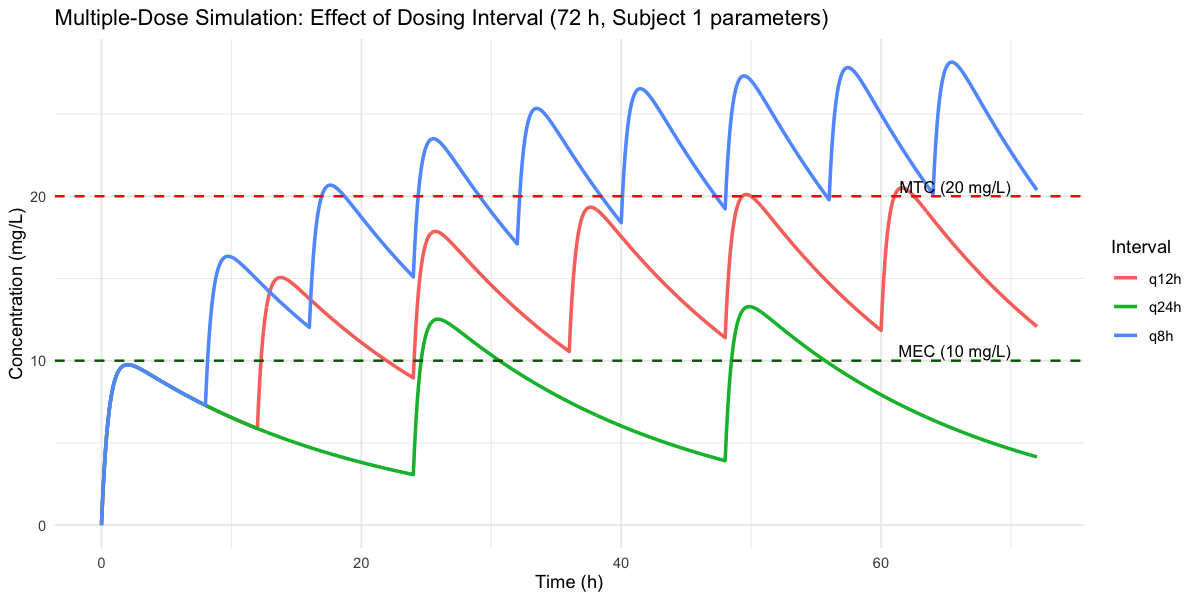

In [11]:
# Multiple oral dosing by superposition
# For each time point t, sum contributions from all doses given up to that time
pk_multidose <- function(t_vec, dose, ka, CL, V, interval, n_doses) {
  sapply(t_vec, function(t) {
    # Dose times: 0, interval, 2*interval, ...
    dose_times <- seq(0, (n_doses - 1) * interval, by = interval)
    total <- 0
    for (t0 in dose_times) {
      if (t >= t0) {  # only include doses that have been given by time t
        total <- total + one_comp_oral(t - t0, dose, ka, CL, V)
      }
    }
    total
  })
}

t_md <- seq(0, 72, by = 0.1)  # 72-hour simulation window

# Simulate q8h, q12h, and q24h dosing
sim_md <- lapply(c(8, 12, 24), function(tau) {
  data.frame(
    Time     = t_md,
    conc     = pk_multidose(t_md,
                            dose     = sub1$Dose[1],
                            ka       = params["ka"],
                            CL       = params["CL"],
                            V        = params["V"],
                            interval = tau,
                            n_doses  = ceiling(72 / tau) + 1),
    Interval = paste0("q", tau, "h")
  )
})

sim_md_df <- do.call(rbind, sim_md)

ggplot(sim_md_df, aes(x = Time, y = conc, color = Interval)) +
  geom_line(linewidth = 1) +
  # Therapeutic window boundaries
  geom_hline(yintercept = 10, linetype = "dashed", color = "darkgreen", linewidth = 0.7) +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red",       linewidth = 0.7) +
  annotate("text", x = 70, y = 10.6, label = "MEC (10 mg/L)", hjust = 1, size = 3.5) +
  annotate("text", x = 70, y = 20.6, label = "MTC (20 mg/L)", hjust = 1, size = 3.5) +
  labs(
    title = "Multiple-Dose Simulation: Effect of Dosing Interval (72 h, Subject 1 parameters)",
    x = "Time (h)", y = "Concentration (mg/L)", color = "Interval"
  ) +
  theme_minimal()

Reading the simulation:

- **q24h (once daily)**: trough concentrations dip below the MEC (10 mg/L) — the patient may experience loss of bronchodilation before the next dose.
- **q8h (three times daily)**: drug accumulates more, and peaks may approach or exceed the MTC (20 mg/L) by steady state — risk of toxicity.
- **q12h (twice daily)**: profiles stay within the 10–20 mg/L therapeutic window at steady state — the most appropriate regimen for this subject.

Note: the MEC and MTC values here (10 and 20 mg/L) are approximate and illustrative; actual theophylline guidelines vary by clinical context.

Steady state is reached after approximately **4–5 half-lives** (here ~15–18 h), which is why the q12h profile stabilizes by the third or fourth dose.

This simulation is the kind of analysis that directly informs the dosing instructions on a drug label — and it was generated in seconds using three numbers (ka, CL, V) from the fitting step.

---
## Part 6: Population PK — Modeling All Subjects Simultaneously

The analysis above fit one subject at a time, estimating ka, CL, and V for each individual independently. This naive approach has three major limitations:

1. **Sparse data**: subjects with only a few observations yield unreliable individual estimates. With 3 observations and 3 parameters, the fit may be exact but meaningless.
2. **Ignoring the grouped structure**: individual fits treat each subject as completely independent and do not use information from the rest of the group.
3. **Cannot estimate variability**: we want to know the *distribution* of CL across the population — not just one subject's value. This distribution is the scientifically and clinically important quantity.

**Nonlinear mixed-effects (NLME) models** solve all three problems simultaneously.

---
### The NLME Framework

<img src="images/nlme.png" width="600">

An NLME model has two levels of equations:

**Level 1 — Within-subject model** (same as before):
$$y_{ij} = f(t_{ij},\, \theta_i) + \varepsilon_{ij}, \qquad \varepsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$$

The observed concentration for subject $i$ at time $j$ equals the model prediction using *that subject's* parameters $\theta_i$, plus residual noise $\varepsilon_{ij}$.

**Level 2 — Between-subject model** (the new piece):
$$\theta_i = \theta_{\text{pop}} + \eta_i, \qquad \eta_i \sim \mathcal{N}(0, \Omega)$$

Each subject's parameters are drawn from a **population distribution**. $\theta_{\text{pop}}$ is the population mean (the "typical" patient), $\eta_i$ is that subject's individual deviation from average, and $\Omega$ is the variance–covariance matrix capturing how much subjects differ.

**What this gives us:**

| Quantity | Meaning | Clinical use |
|---|---|---|
| Fixed effects $\theta_{\text{pop}}$ | Average ka, CL, V across population | Starting point for dose selection |
| Random effects variance $\Omega$ | How much individuals differ | Drives need for therapeutic drug monitoring |
| % coefficient of variation (%CV) of CL | Relative spread of CL in population | >30–40% flags need for dose individualization |
| Residual variance $\sigma^2$ | Unexplained noise within a subject | Measurement error + model misspecification |

**Borrowing strength**: subjects with few observations have their individual estimates "shrunk" toward the population mean. This is statistically conservative and more reliable than trusting a noisy individual estimate.

R's `nlme` package implements NLME models. We fit ka, CL, and V as fixed effects (population means) and allow CL and V to have subject-specific random effects (ka is often harder to estimate from sparse data and is held fixed).

In [12]:
library(nlme)

# Fit the one-compartment oral model to all 12 subjects simultaneously
# fixed  = parameters with population-level means
# random = parameters allowed to vary by Subject (diagonal = independent random effects)
# groups = which column identifies subjects
fit_nlme <- nlme(
  conc ~ one_comp_oral(Time, Dose, ka, CL, V),
  data   = Theoph,
  fixed  = ka + CL + V ~ 1,
  random = pdDiag(CL + V ~ 1),
  groups = ~ Subject,
  start  = c(ka = 1.5, CL = 0.04, V = 0.5)
)

summary(fit_nlme)


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse




Nonlinear mixed-effects model fit by maximum likelihood
  Model: conc ~ one_comp_oral(Time, Dose, ka, CL, V) 
  Data: Theoph 
       AIC      BIC    logLik
  433.6965 450.9933 -210.8482

Random effects:
 Formula: list(CL ~ 1, V ~ 1)
 Level: Subject
 Structure: Diagonal
                 CL          V Residual
StdDev: 0.009850092 0.09264913 1.018627

Fixed effects:  ka + CL + V ~ 1 
       Value  Std.Error  DF  t-value p-value
ka 1.5157373 0.12327457 118 12.29562       0
CL 0.0398421 0.00352257 118 11.31050       0
V  0.4735646 0.03151612 118 15.02611       0
 Correlation: 
   ka     CL    
CL -0.250       
V   0.372 -0.165

Standardized Within-Group Residuals:
        Min          Q1         Med          Q3         Max 
-2.18786371 -0.48709006 -0.02343464  0.29783105  3.55810661 

Number of Observations: 132
Number of Groups: 12 

The summary reports fixed-effect estimates and their standard errors, plus the estimated random-effect standard deviations (the square roots of the diagonal of $\Omega$).

Let's extract the key results and present them more clearly.

In [13]:
# Extract population (fixed) effects
fe <- fixef(fit_nlme)

# Extract between-subject standard deviations from the variance-covariance table
# VarCorr returns a character matrix; we need numeric standard deviations
vc <- VarCorr(fit_nlme)
re_sd <- as.numeric(vc[c("CL", "V"), "StdDev"])

cat("=== Population PK Estimates (all 12 subjects) ===\n")
cat(sprintf("  ka  (pop mean) = %.3f h-1\n", fe["ka"]))
cat(sprintf("  CL  (pop mean) = %.4f L/kg/h  |  between-subject SD = %.4f\n",
            fe["CL"], re_sd[1]))
cat(sprintf("  V   (pop mean) = %.3f L/kg    |  between-subject SD = %.4f\n",
            fe["V"], re_sd[2]))
cat(sprintf("\n  CL between-subject CV = %.0f%%\n",
            100 * re_sd[1] / fe["CL"]))
cat(sprintf("  V  between-subject CV  = %.0f%%\n",
            100 * re_sd[2] / fe["V"]))

=== Population PK Estimates (all 12 subjects) ===
  ka  (pop mean) = 1.516 h-1
  CL  (pop mean) = 0.0398 L/kg/h  |  between-subject SD = 0.0099
  V   (pop mean) = 0.474 L/kg    |  between-subject SD = 0.0926

  CL between-subject CV = 25%
  V  between-subject CV  = 20%


The **%CV** (coefficient of variation) of CL tells us how variable clearance is across the population. A value of, say, 30% means the standard deviation is 30% of the mean — substantial variability that could translate to large differences in drug exposure at a fixed dose.

Now let's visualize how well the model fits each subject, showing both individual predictions (which use each subject's estimated $\eta_i$) and population predictions (which set all $\eta_i = 0$, representing a "typical" patient).

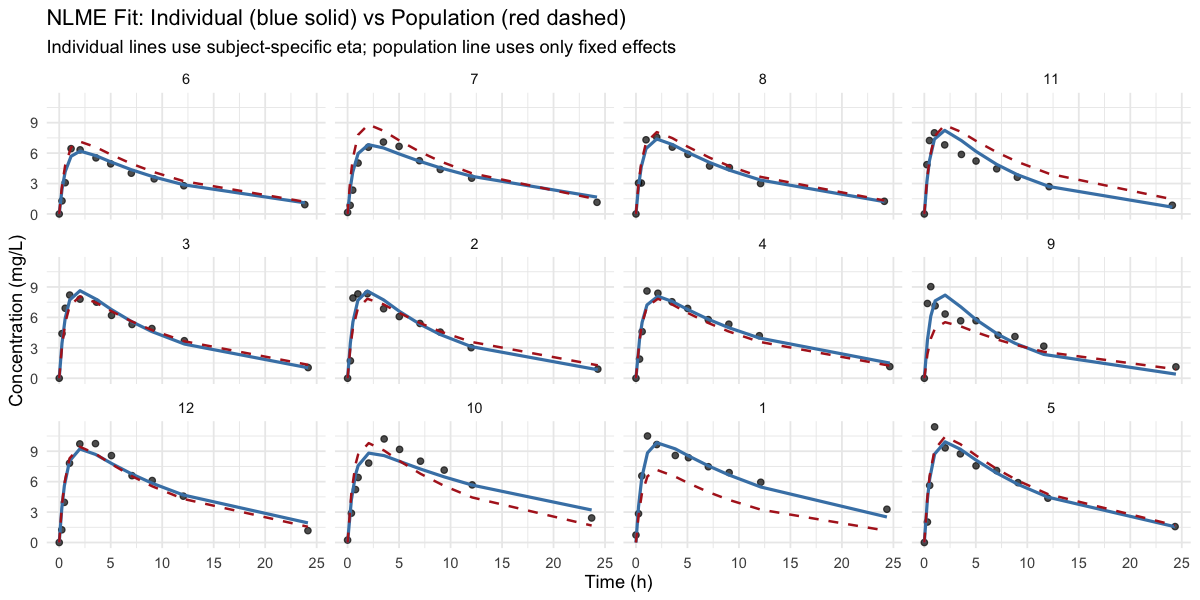

In [14]:
# Add predictions to the Theoph data frame
theoph_plot <- Theoph
theoph_plot$pred_ind <- predict(fit_nlme)           # individual predictions (level = 1)
theoph_plot$pred_pop <- predict(fit_nlme, level = 0) # population predictions (eta = 0)

ggplot(theoph_plot, aes(x = Time, y = conc)) +
  geom_point(size = 1.5, alpha = 0.7) +
  geom_line(aes(y = pred_ind), color = "steelblue",  linewidth = 0.9) +
  geom_line(aes(y = pred_pop), color = "firebrick",  linewidth = 0.7, linetype = "dashed") +
  facet_wrap(~ Subject, ncol = 4) +
  labs(
    title    = "NLME Fit: Individual (blue solid) vs Population (red dashed)",
    subtitle = "Individual lines use subject-specific eta; population line uses only fixed effects",
    x = "Time (h)", y = "Concentration (mg/L)"
  ) +
  theme_minimal()

Reading the faceted plot:

- **Blue solid lines** (individual predictions): use each subject's estimated $\eta_i$, so they are personalized to that subject's data. They should track the dots closely.
- **Red dashed lines** (population predictions): set $\eta_i = 0$, representing what the model predicts for a *typical* subject with average CL and V. These lines are the same shape for everyone, just scaled by each subject's dose.

The **gap between solid and dashed** lines tells you how atypical each subject is. A subject whose blue and red lines nearly coincide has parameters close to the population average. A subject where they diverge substantially has an unusually high or low CL or V — exactly the kind of outlier you would flag for further investigation (could their genotype explain it? their smoking status? a drug interaction?).

This diagnostic plot — individual vs. population predictions — is one of the first things a pharmacometrician examines when evaluating a population PK model.

---
## Part 7: PD Modeling — From Concentration to Effect

PK tells us how concentration changes over time. PD connects concentration to pharmacological effect. The most important and widely used PD model is the **Emax (Hill) model**, derived from receptor occupancy theory.

---
### The Emax Model

$$E(C) = E_0 + \frac{E_{\max} \cdot C^n}{EC_{50}^n + C^n}$$

For simplicity, we often use $n = 1$ (no cooperativity) and $E_0 = 0$ (no baseline effect):

$$E(C) = \frac{E_{\max} \cdot C}{EC_{50} + C}$$

**Parameters:**

| Symbol | Meaning |
|---|---|
| $E_{\max}$ | Maximum achievable effect (100% for a full agonist) |
| $EC_{50}$ | Concentration producing half-maximal effect — a measure of **potency** |
| $n$ | Hill coefficient — $n > 1$ means cooperativity (sigmoidal curve), $n = 1$ gives a simple hyperbola |

**Key properties:**
- At $C \ll EC_{50}$: $E \approx (E_{\max}/EC_{50}) \cdot C$ — linear, proportional to concentration
- At $C = EC_{50}$: $E = E_{\max}/2$ — half-maximal effect
- At $C \gg EC_{50}$: $E \approx E_{\max}$ — saturation, further dose increases give diminishing returns

The Emax model is the pharmacological analog of the Michaelis-Menten equation from enzyme kinetics — the same mathematics, just applied to receptor binding instead of substrate binding.

Let's visualize the shape of the Emax model and how EC50 affects potency.

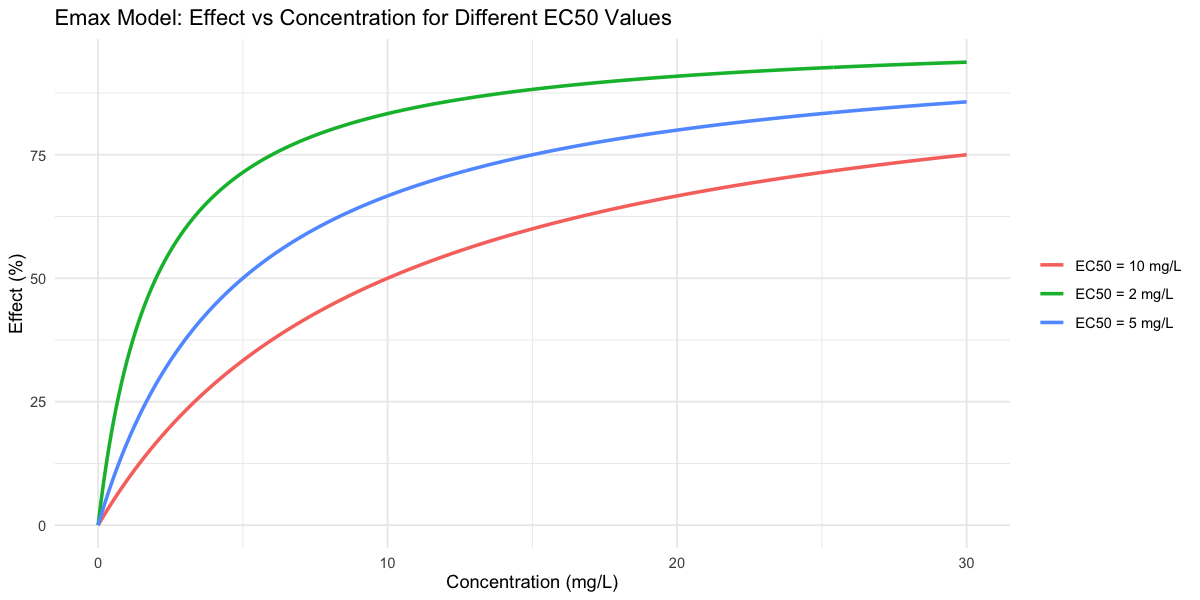

In [15]:
C_seq <- seq(0, 30, by = 0.1)

# Simulate Emax model for three EC50 values
emax_sim <- expand.grid(C = C_seq, EC50 = c(2, 5, 10)) %>%
  mutate(
    E     = 100 * C / (EC50 + C),
    label = paste0("EC50 = ", EC50, " mg/L")
  )

ggplot(emax_sim, aes(x = C, y = E, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Emax Model: Effect vs Concentration for Different EC50 Values",
    x = "Concentration (mg/L)", y = "Effect (%)", color = NULL
  ) +
  theme_minimal()

A lower EC50 means the drug is **more potent** — it achieves the same fractional effect at a lower concentration. Compare the EC50 = 2 curve with the EC50 = 10 curve: at 5 mg/L, the potent drug (EC50 = 2) is already at ~71% maximum effect, while the weaker drug (EC50 = 10) is only at ~33%.

Notice that all three curves converge to the same Emax = 100%. Potency (EC50) and efficacy (Emax) are different concepts:
- A highly potent drug achieves its effect at low concentrations but may have a low Emax (partial agonist)
- A low-potency drug may require high concentrations but achieves full effect (full agonist)

**The steep part of the curve is therapeutically useful**; once you are above ~3–4× EC50, you are on the flat part and further dose increases provide diminishing benefit.

---
### Generating Synthetic PD Data and Fitting the Emax Model

We will generate synthetic effect data for Subject 2, adding realistic measurement noise. This mimics real PD data — effect measurements always have scatter.

We pretend to know the "true" PD parameters (Emax = 100, EC50 = 5 mg/L) and generate noisy measurements around the true curve. The fitting exercise is to recover those parameters from the noisy data.

In [16]:
set.seed(42)  # for reproducibility

sub2 <- subset(Theoph, Subject == 2)

# True PD parameters (pretend these are unknown — we'll estimate them)
Emax_true <- 100
EC50_true <- 5

# Generate noisy effect measurements at each observed concentration
# rnorm adds Gaussian noise with SD = 4 (measurement variability)
sub2$effect <- Emax_true * sub2$conc / (EC50_true + sub2$conc) +
               rnorm(nrow(sub2), mean = 0, sd = 4)
sub2$effect <- pmax(sub2$effect, 0)  # effects cannot be negative

head(sub2[, c("Subject", "Time", "conc", "effect")])

,Subject,Time,conc,effect
,<ord>,<dbl>,<dbl>,<dbl>
12,2,0.00,0.00,5.483834
13,2,0.27,1.72,23.336445
14,2,0.52,7.91,62.722847
15,2,1.00,8.31,64.965710
16,2,1.92,8.33,64.107696
17,2,3.50,6.85,57.381409


The `effect` column now contains noisy measurements of bronchodilation (as a %) at each observed concentration. In a real study, this might be FEV1 improvement, pain relief score, or enzyme inhibition measured at each blood draw.

Now let's fit the Emax model to these data.

In [17]:
# Fit the Emax model using nls()
# Starting values: Emax near 80 (conservative), EC50 near 8
fit_emax <- nls(
  effect ~ Emax * conc / (EC50 + conc),
  data  = sub2,
  start = list(Emax = 80, EC50 = 8)
)

summary(fit_emax)

emax_params <- coef(fit_emax)
cat(sprintf("\nFitted Emax = %.1f  (true = 100)\n", emax_params["Emax"]))
cat(sprintf("Fitted EC50 = %.2f mg/L  (true = 5.00 mg/L)\n", emax_params["EC50"]))


Formula: effect ~ Emax * conc/(EC50 + conc)

Parameters:
     Estimate Std. Error t value Pr(>|t|)    
Emax   99.764     10.652   9.365 6.16e-06 ***
EC50    4.533      1.116   4.062  0.00284 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.816 on 9 degrees of freedom

Number of iterations to convergence: 4 
Achieved convergence tolerance: 9.129e-07



Fitted Emax = 99.8  (true = 100)
Fitted EC50 = 4.53 mg/L  (true = 5.00 mg/L)


Despite the noise, `nls()` recovers the true parameter values reasonably well. The fitted Emax and EC50 should be close to 100 and 5, respectively. The remaining discrepancy is due to random noise — with more data points or less noise, the estimates would be tighter.

Note the standard errors: EC50 often has larger relative uncertainty than Emax because it is estimated from the steepest part of the curve, which is sparsely sampled in typical PK/PD studies. Getting a precise EC50 estimate requires deliberately designed studies with concentrations spanning a wide range — ideally centered on EC50 itself.

Now let's plot the fit.

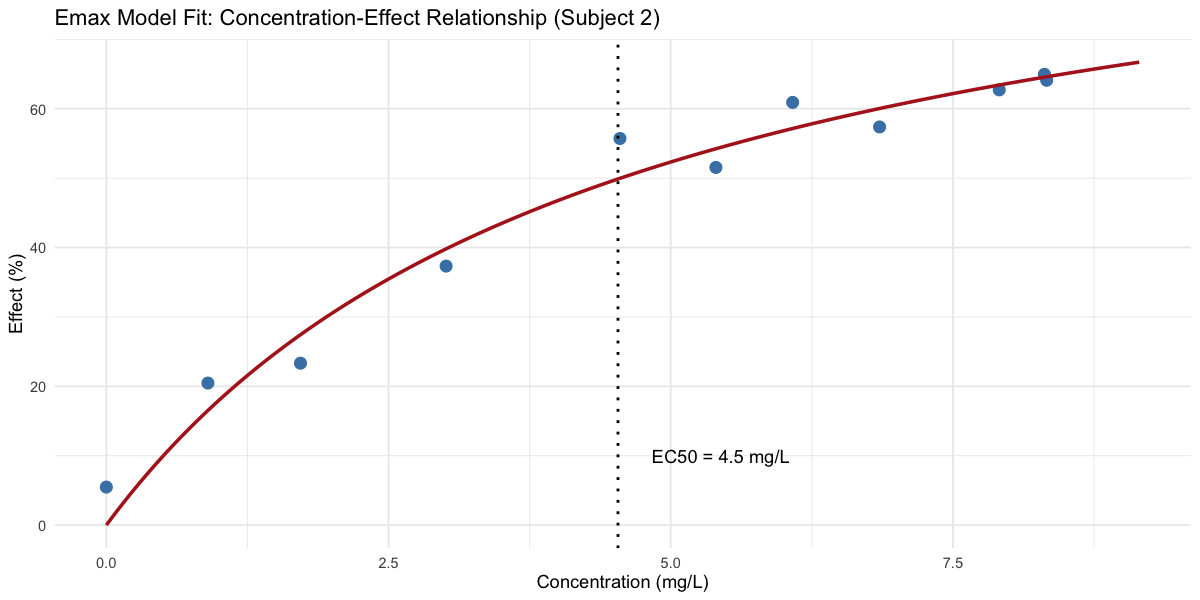

In [18]:
# Generate smooth model curve for plotting
C_fine <- seq(0, max(sub2$conc) * 1.1, by = 0.05)
emax_pred_df <- data.frame(
  conc   = C_fine,
  effect = emax_params["Emax"] * C_fine / (emax_params["EC50"] + C_fine)
)

ggplot() +
  geom_point(data = sub2, aes(x = conc, y = effect),
             size = 3, color = "steelblue") +
  geom_line(data = emax_pred_df, aes(x = conc, y = effect),
            color = "firebrick", linewidth = 1) +
  # Mark the EC50
  geom_vline(xintercept = emax_params["EC50"], linetype = "dotted", linewidth = 0.8) +
  annotate("text",
           x     = emax_params["EC50"] + 0.3,
           y     = 10,
           label = paste0("EC50 = ", round(emax_params["EC50"], 1), " mg/L"),
           hjust = 0) +
  labs(
    title = "Emax Model Fit: Concentration-Effect Relationship (Subject 2)",
    x = "Concentration (mg/L)", y = "Effect (%)"
  ) +
  theme_minimal()

The sigmoidal (actually hyperbolic, since n = 1) curve captures the diminishing-returns nature of the concentration-effect relationship. The dotted vertical line marks the EC50 — where the model predicts 50% of Emax.

Now let's look at this over time, combining the PK profile with the PD predictions.

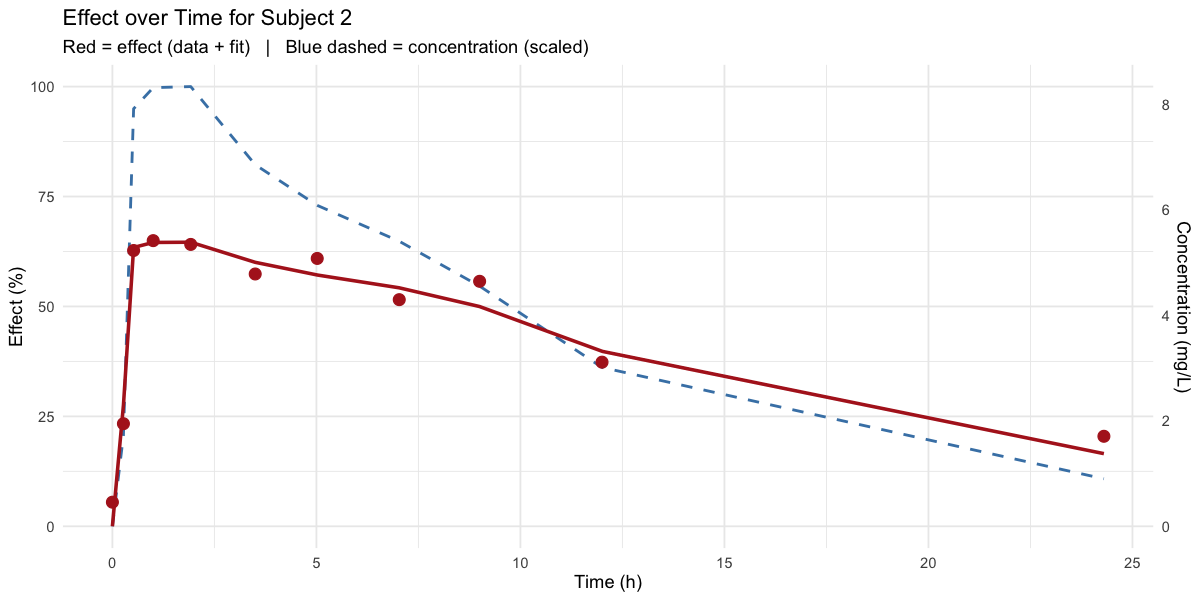

In [19]:
# Predict effect at each observed time using the fitted Emax model
sub2$effect_pred <- predict(fit_emax)

# Scale concentration onto the effect axis for dual-axis display
# (purely for visual overlay — the two y-axes have different units)
scale_factor <- 100 / max(sub2$conc)

ggplot(sub2, aes(x = Time)) +
  # Concentration (scaled to fit effect axis), shown as dashed blue line
  geom_line(aes(y = conc * scale_factor), color = "steelblue",
            linetype = "dashed", linewidth = 0.8) +
  # Observed effects (red dots)
  geom_point(aes(y = effect), color = "firebrick", size = 3) +
  # Predicted effects (red line)
  geom_line(aes(y = effect_pred), color = "firebrick", linewidth = 1) +
  scale_y_continuous(
    name     = "Effect (%)",
    sec.axis = sec_axis(~ . / scale_factor, name = "Concentration (mg/L)")
  ) +
  labs(
    title    = "Effect over Time for Subject 2",
    subtitle = "Red = effect (data + fit)   |   Blue dashed = concentration (scaled)",
    x = "Time (h)"
  ) +
  theme_minimal()

This plot reveals a key insight: **concentration and effect do not track perfectly**.

Observe that:
- At early times (low concentration, on the steep part of the Emax curve), small changes in concentration produce relatively large changes in effect
- At peak concentration (around 1–2 h), the effect is near saturation — the curve is flat, so even though concentration is high, further small increases barely change the effect
- As concentration falls, effect decreases again

In more complex drugs, the effect can genuinely **lag** behind the PK — the drug must cross the blood-brain barrier, bind to a receptor inside a cell, or trigger a downstream signaling cascade before the measured effect is observed. This time delay is modeled using an **effect compartment** (or link model), which is beyond today's scope but is a natural extension of what we've built here.

---
## Part 8: Numerical ODE Solvers — Going Beyond Analytic Solutions

All the models we've used so far have closed-form analytic solutions: plug in $t$, get $C(t)$. This works because the ODEs are linear with constant coefficients.

But many important pharmacological models are **nonlinear**:
- Saturable (Michaelis-Menten) elimination: $\frac{dC}{dt} = -\frac{V_{\max} \cdot C}{K_m + C}$
- Target-mediated drug disposition (TMDD): drug binds to its pharmacological target
- Systems models with feedback loops (e.g., glucose-insulin dynamics)

For these, analytic solutions don't exist. We need **numerical ODE solvers**: algorithms that step forward in time, approximating the solution by computing small increments.

R's `deSolve` package provides the `ode()` function, which implements robust solvers (including LSODA, which automatically handles stiff vs. non-stiff systems). The interface is always the same regardless of ODE complexity.

Let's implement the 1-compartment oral model numerically using `deSolve` and verify it matches our analytic solution exactly.

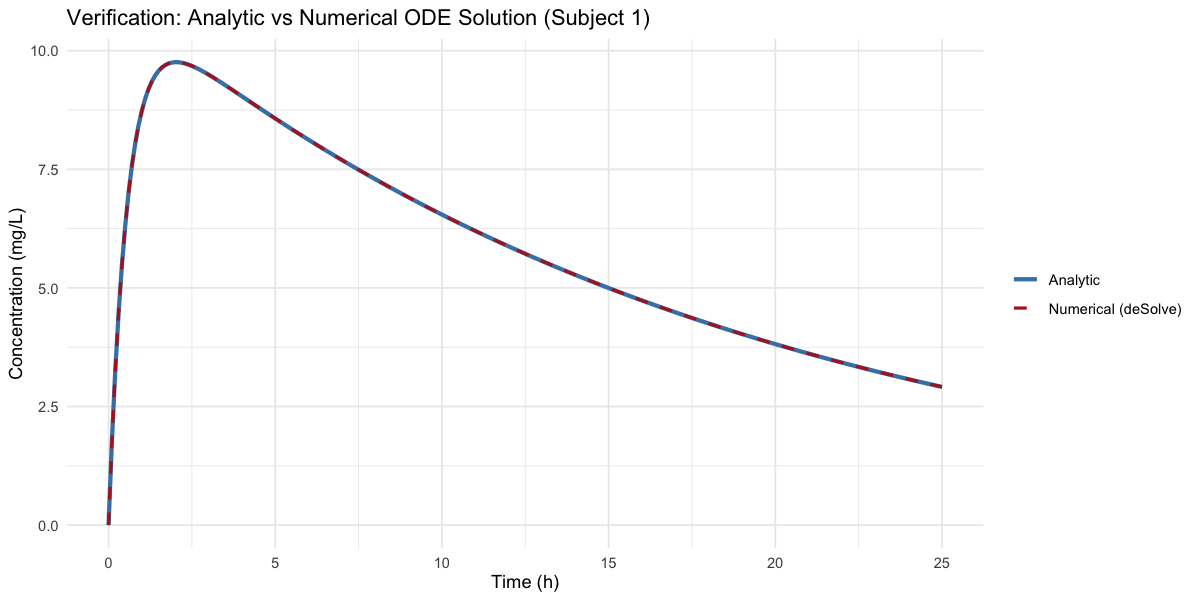

In [20]:
library(deSolve)

# Define the ODE system as a function
# Arguments: time (scalar), state (named vector), params (named vector)
# Returns: list with derivatives in the same order as state
pk_ode <- function(time, state, params) {
  with(as.list(c(state, params)), {
    ke      <- CL / V
    dDepot   <- -ka * Depot        # drug leaving the gut
    dCentral <- ka * Depot - ke * Central  # drug entering minus drug eliminated
    list(c(dDepot, dCentral))
  })
}

# Parameters (use Subject 1 fitted values)
ode_params <- c(ka = params[["ka"]], CL = params[["CL"]], V = params[["V"]])

# Initial conditions: all drug starts in the Depot
# Central = 0 because no drug has absorbed yet
init_state <- c(Depot = sub1$Dose[1], Central = 0)

times <- seq(0, 25, by = 0.1)

# Solve the ODE system
ode_out <- ode(y = init_state, times = times, func = pk_ode, parms = ode_params)
ode_df  <- as.data.frame(ode_out)

# Convert central compartment AMOUNT to CONCENTRATION (divide by V)
ode_df$C_numeric  <- ode_df$Central / params["V"]

# Also compute the analytic solution for comparison
ode_df$C_analytic <- pk_oral(times, sub1$Dose[1],
                             params["ka"], params["CL"], params["V"])

# Plot both
ggplot(ode_df, aes(x = time)) +
  geom_line(aes(y = C_analytic, color = "Analytic"),         linewidth = 1.2) +
  geom_line(aes(y = C_numeric,  color = "Numerical (deSolve)"),
            linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(values = c("Analytic" = "steelblue",
                                "Numerical (deSolve)" = "firebrick")) +
  labs(
    title = "Verification: Analytic vs Numerical ODE Solution (Subject 1)",
    x = "Time (h)", y = "Concentration (mg/L)", color = NULL
  ) +
  theme_minimal()

The two solutions overlap essentially perfectly — confirming that our analytic formula and the numerical solver agree to graphical precision.

The `deSolve` approach generalizes to arbitrarily complex models. To add Michaelis-Menten elimination, you would simply replace the `-ke * Central` term with `-Vmax * Central / (Km * V + Central)` in the `pk_ode` function — no other changes needed.

For reference, here is how you would add a third compartment (peripheral distribution):

```r
# Example: 2-compartment model structure (not run)
pk_2cpt_ode <- function(time, state, params) {
  with(as.list(c(state, params)), {
    ke    <- CL / V1
    dDepot      <- -ka * Depot
    dCentral    <-  ka * Depot - ke * Central - k12 * Central + k21 * Peripheral
    dPeripheral <-  k12 * Central - k21 * Peripheral
    list(c(dDepot, dCentral, dPeripheral))
  })
}
```

The code structure is identical — just more state variables and more terms.

---
### Case Study: Tumor Growth Inhibition — Simeoni et al. (2004)

The PK/PD framework extends naturally to oncology, where the pharmacodynamic readout is **tumor volume or weight over time** rather than a molecular endpoint. A landmark model was published by [Simeoni et al.](https://aacrjournals.org/cancerres/article/64/3/1094/512264/Predictive-Pharmacokinetic-Pharmacodynamic) in *Cancer Research* (2004) to quantitatively describe the anti-tumor activity of CPT-11 (irinotecan, a topoisomerase I inhibitor) in xenograft mouse models.

**Why this model matters in drug development:**  
In preclinical oncology, the Simeoni model — often called the **TGI model** (Tumor Growth Inhibition) — is used to extract a dose-independent drug potency parameter ($k_2$) from mouse data, then *simulate* expected tumor responses at untested doses, including translation to first-in-human dose selection.

---

#### Biological Rationale

<img src="images/simeoni-tgi.png" width="500">

**1. Growth dynamics: exponential → linear switch**

Small, well-vascularized tumors grow exponentially. As the tumor enlarges, vascular supply becomes limiting and net growth transitions to **linear** in total mass. The model captures both regimes with a single smooth equation:

$$\frac{dw_{\text{growth}}}{dt} = \frac{\lambda_0\, x_1}{\left[1 + \left(\dfrac{\lambda_0\, w}{\lambda_1}\right)^\Psi\right]^{1/\Psi}}$$

- When $w$ is small: denominator ≈ 1, rate ≈ $\lambda_0 x_1$ — **exponential** growth
- When $w$ is large: rate ≈ $\lambda_1$ — **linear** growth (constant g/day)
- $\Psi = 20$: makes the transition sharp but numerically smooth

The crossover occurs near $w^* = \lambda_1 / \lambda_0$.

**2. Delayed drug effect: transit compartment cascade**

Cytotoxic drugs trigger apoptosis or mitotic catastrophe — processes that take **days**, not hours. A chain of three transit compartments ($x_2 \to x_3 \to x_4$) introduces a biologically motivated delay:

$$\frac{dx_1}{dt} = \text{growth} - k_2\, c(t)\, x_1 \qquad \text{(proliferating cells)}$$
$$\frac{dx_i}{dt} = k_1\, x_{i-1} - k_1\, x_i \qquad (i = 2,\, 3,\, 4) \qquad \text{(damaged stages)}$$

Drug ($k_2 c(t)$) moves proliferating cells from $x_1$ into $x_2$; they cascade through $x_3 \to x_4$ and then disappear. Total tumor weight $w = x_1 + x_2 + x_3 + x_4$. The mean delay from damage to cell clearance is $3/k_1$ days.

**3. Drug concentration: 2-compartment PK model**

CPT-11 is modeled with a standard 2-compartment IV bolus PK, where the plasma concentration $c(t)$ drives the cell-kill term. Parameters are from Table 1 of the paper (xenograft mice).

| Parameter | Value | Units | Meaning |
|---|---|---|---|
| $\lambda_0$ | 0.146 | day⁻¹ | Exponential tumor growth rate |
| $\lambda_1$ | 0.334 | g·day⁻¹ | Linear tumor growth rate |
| $k_1$ | 0.469 | day⁻¹ | Transit rate between damaged compartments |
| $k_2$ | 8.42 × 10⁻⁴ | (ng/mL)⁻¹·day⁻¹ | Drug potency (cell-kill per unit concentration per day) |
| $w_0$ | 0.085 | g | Initial tumor weight |
| $V_1$ | 4.85 | L/kg | Central PK volume |
| $k_{10}$ | 0.553 | h⁻¹ | Elimination rate constant |

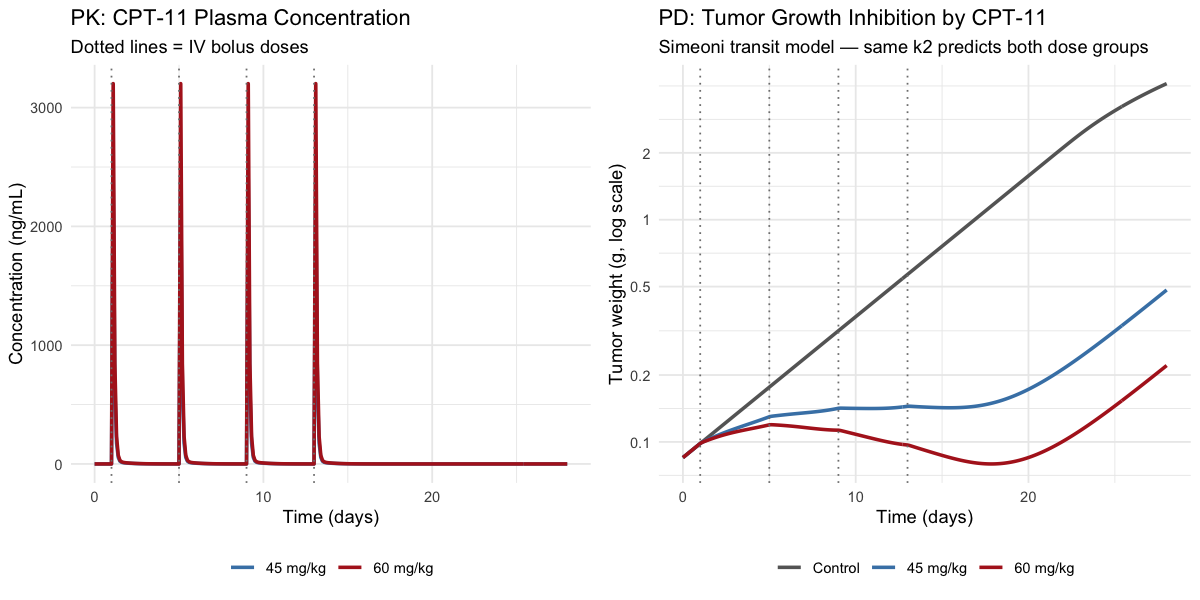

In [21]:
# =========================================================
# Simeoni et al. (2004): CPT-11 Tumor Growth Inhibition Model
# Parameters from Table 1; time unit = days throughout
# =========================================================

# --- 2-compartment PK parameters (h⁻¹ converted to day⁻¹) ---
V1  <- 4.85            # L/kg  — central volume of distribution
k10 <- 0.553  * 24    # day⁻¹ — elimination from central compartment
k12 <- 0.0115 * 24    # day⁻¹ — central → peripheral transfer
k21 <- 0.0616 * 24    # day⁻¹ — peripheral → central transfer

# --- Simeoni TGI model parameters ---
lambda0 <- 0.146      # day⁻¹          — exponential growth rate constant
lambda1 <- 0.334      # g·day⁻¹        — linear growth rate constant
k1      <- 0.469      # day⁻¹          — transit compartment rate
k2      <- 8.42e-4    # (ng/mL)⁻¹·day⁻¹ — drug potency / cell-kill rate
Psi     <- 20         # (dimensionless) — growth-switch smoothness
w0      <- 0.085      # g              — initial tumor weight

params_sim <- c(V1 = V1, k10 = k10, k12 = k12, k21 = k21,
                lambda0 = lambda0, lambda1 = lambda1,
                k1 = k1, k2 = k2, Psi = Psi)

# ---- ODE system -------------------------------------------------------
# State variables:
#   A1, A2 : drug amount in central / peripheral compartment  [mg/kg]
#   x1     : proliferating tumor cells                        [g]
#   x2, x3, x4 : damaged cells in transit stages 1–3         [g]
simeoni_ode <- function(t, state, params) {
  with(as.list(c(state, params)), {

    # Drug concentration: mg/kg ÷ L/kg = mg/L; × 1000 → ng/mL
    c_drug <- max(A1 / V1 * 1000, 0)

    # 2-compartment PK (amounts in mg/kg, rates in day⁻¹)
    dA1 <- -(k10 + k12) * A1 + k21 * A2
    dA2 <-  k12 * A1 - k21 * A2

    # Total tumor weight
    w <- x1 + x2 + x3 + x4

    # Smooth exponential → linear growth switch (Simeoni Eq. E)
    growth_rate <- lambda0 * x1 / (1 + (lambda0 / lambda1 * w)^Psi)^(1/Psi)

    # Tumor PD: drug kills proliferating cells → transit cascade
    dx1 <- growth_rate  - k2 * c_drug * x1
    dx2 <- k2 * c_drug * x1 - k1 * x2
    dx3 <- k1 * x2 - k1 * x3
    dx4 <- k1 * x3 - k1 * x4

    list(c(dA1, dA2, dx1, dx2, dx3, dx4))
  })
}

# ---- Simulation helper ------------------------------------------------
# Dose given IV bolus on days 1, 5, 9, 13 (q4d × 4; typical mouse schedule)
dose_days <- c(1, 5, 9, 13)

run_tgi <- function(dose_mgkg) {
  y0    <- c(A1 = 0, A2 = 0, x1 = w0, x2 = 0, x3 = 0, x4 = 0)
  times <- seq(0, 28, by = 0.1)

  if (dose_mgkg > 0) {
    # deSolve events: add dose amount to A1 at each dosing time (IV bolus)
    ev <- data.frame(var = "A1", time = dose_days,
                     value = dose_mgkg, method = "add")
    out <- ode(y = y0, times = times, func = simeoni_ode,
               parms = params_sim, events = list(data = ev), method = "lsoda")
  } else {
    out <- ode(y = y0, times = times, func = simeoni_ode,
               parms = params_sim, method = "lsoda")
  }

  df            <- as.data.frame(out)
  df$tumor_g    <- df$x1 + df$x2 + df$x3 + df$x4
  df$c_ng_mL    <- pmax(df$A1 / V1 * 1000, 0)
  df$group      <- if (dose_mgkg == 0) "Control" else paste0(dose_mgkg, " mg/kg")
  df
}

# ---- Run three scenarios: vehicle control, 45 mg/kg, 60 mg/kg ---------
sim_all <- do.call(rbind, lapply(c(0, 45, 60), run_tgi))
sim_all$group <- factor(sim_all$group, levels = c("Control", "45 mg/kg", "60 mg/kg"))

cols <- c("Control" = "gray40", "45 mg/kg" = "steelblue", "60 mg/kg" = "firebrick")

# ---- Panel 1: PK — plasma concentration (first 10 days shown) ---------
p_pk <- ggplot(
    subset(sim_all, group != "Control"),
    aes(x = time, y = c_ng_mL, color = group)
  ) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = dose_days,
             linetype = "dotted", color = "gray50") +
  scale_color_manual(values = cols) +
  labs(
    title    = "PK: CPT-11 Plasma Concentration",
    subtitle = "Dotted lines = IV bolus doses",
    x = "Time (days)", y = "Concentration (ng/mL)", color = NULL
  ) +
  theme_minimal() + theme(legend.position = "bottom")

# ---- Panel 2: PD — tumor growth inhibition ----------------------------
p_tgi <- ggplot(sim_all, aes(x = time, y = tumor_g, color = group)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = dose_days,
             linetype = "dotted", color = "gray50", linewidth = 0.5) +
  scale_y_log10(breaks = c(0.05, 0.1, 0.2, 0.5, 1, 2, 5),
                labels = as.character(c(0.05, 0.1, 0.2, 0.5, 1, 2, 5))) +
  scale_color_manual(values = cols) +
  labs(
    title    = "PD: Tumor Growth Inhibition by CPT-11",
    subtitle = "Simeoni transit model — same k2 predicts both dose groups",
    x = "Time (days)", y = "Tumor weight (g, log scale)", color = NULL
  ) +
  theme_minimal() + theme(legend.position = "bottom")

grid.arrange(p_pk, p_tgi, ncol = 2)

**Reading the simulation:**

**Left panel — PK:** CPT-11 is very rapidly eliminated ($k_{10} = 0.553$ h⁻¹, $t_{1/2} \approx 1.25$ h). Each IV bolus produces a sharp concentration spike that falls to near-zero within a day. Drug effect on cells is therefore brief and pulsatile — most cell killing happens in the first few hours after each dose.

**Right panel — TGI (log scale):**

- **Control (gray):** Unperturbed exponential growth early, transitioning toward linear growth around day 20–22 as the tumor approaches the crossover weight $w^* = \lambda_1/\lambda_0 \approx 2.3$ g.

- **45 mg/kg (blue):** Each dose kills a fraction of proliferating cells. The tumor doesn't shrink immediately — the damaged cells (in $x_2$–$x_4$) still contribute to total weight. Regression becomes visible after ~6–8 days (the mean transit delay $= 3/k_1 \approx 6.4$ days). After dosing stops on day 13, the surviving $x_1$ cells resume growth.

- **60 mg/kg (red):** Greater cell kill per dose leads to more pronounced regression and a longer period before regrowth. The **same $k_2$ parameter** describes both dose groups — the difference is purely a consequence of higher dose (higher $c(t)$, more cell kill per event).

**The key insight for drug development:** Once $k_2$ is estimated from *any* dose group, the model can predict the response at untested doses. In practice, researchers fit the model to multiple dose groups simultaneously (as Simeoni did), verify that $k_2$ is dose-independent, then simulate what dosing schedule would be required to achieve tumor stasis or a specific level of TGI — information that feeds directly into clinical trial design.

This is the same PK/PD pipeline we built throughout this lecture — just with a more complex PD model requiring a numerical ODE solver rather than an analytic formula.

---
## Summary

| Section | Key concept | Take-home message |
|---|---|---|
| PK vs PD | ADME defines the PK problem; receptor occupancy defines the PD problem | Dose → C(t) → E(t) is the complete quantitative chain |
| 1-cpt IV bolus | $C(t) = (D/V)e^{-k_e t}$, with $k_e = CL/V$ | Half-life depends on both CL and V — do not interpret it without both |
| 1-cpt oral | Sum of two exponentials; absorption precedes elimination | ka, CL, V together fully characterize the oral PK profile |
| NLS fitting | `nls()` minimizes sum of squared residuals | Starting values matter; fitted parameters carry biological meaning |
| Simulation | Superposition allows multiple-dose prediction from single-dose parameters | A fitted model can answer questions the original study never tested |
| Population PK | NLME adds a between-subject level: $\theta_i = \theta_{\text{pop}} + \eta_i$ | Quantifies IIV; borrowing strength improves individual estimates |
| Emax PD | $E = E_{\max} C / (EC_{50} + C)$ — saturating hyperbola | EC50 = potency; Emax = efficacy; above ~3×EC50 you are on the flat part |
| Numerical solvers | `deSolve::ode()` solves any ODE system numerically | Extends the same framework to nonlinear, multi-compartment models |
| Simeoni TGI model | Exponential→linear growth + transit compartment cell death cascade | $k_2$ is dose-independent — fit to one dose group, predict all others |

---
### Where to Go Next

**More sophisticated PK/PD tools:**
- **NONMEM** (industry standard) or **Monolix** (modern, GUI-based): dedicated NLME software for drug development
- **mrgsolve** (R package): fast C++ ODE simulation within R — the workhorse for clinical trial simulation
- **rxode2** / **nlmixr2**: open-source R-based NLME fitting with NONMEM-like syntax

**Key extensions to explore:**
- **Effect compartment (Ke0) model**: adds a delay between plasma PK and the site of action — handles PK/PD hysteresis
- **Indirect response models**: for drugs whose effects work through turnover of an endogenous mediator (e.g., corticosteroids, warfarin)
- **Covariate modeling**: test whether body weight, renal function, or genotype explains part of IIV in CL or V
- **Model diagnostics**: goodness-of-fit plots, visual predictive checks (VPC), bootstrap confidence intervals
- **PBPK models**: fully physiological models that predict PK *a priori* from drug properties (logP, pKa, protein binding) and physiology
- **Translational TGI modeling**: scale Simeoni model $k_2$ from mouse to human using allometric scaling and exposure-matching

**Recommended reading:**
- Gabrielsson & Weiner, *Pharmacokinetic and Pharmacodynamic Data Analysis* (classic textbook)
- Bonate, *Pharmacokinetic-Pharmacodynamic Modeling and Simulation* (practical, R-focused)
- Mould & Upton (2012), CPT:PSP — "Basic Concepts in Population Modeling, Simulation, and Model-Based Drug Development"
- Simeoni et al. (2004), *Cancer Research* 64:1094–1101 — the TGI model paper

---

**Additional learning resources:**

- I am currently developing a more structured course on PK/PD and model-informed drug development at  
  **https://aeacademypmx.com**  

  The material is not fully launched yet, but it will cover these topics in more depth, including hands-on modeling, population PK/PD, and simulation workflows.

  If you are interested in going deeper, you are welcome to check it out as it develops.